IMAGE CLASSIFICATION (CIFAR-10)

In [1]:
import tensorflow as tf

# Enable Memory Growth (Still required for the 1050 Ti's 4GB VRAM limit)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("TF 2.15 with CuDNN 8 initialized. Memory growth enabled.")
    except RuntimeError as e:
        print(e)

2026-07-17 04:24:38.180414: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-17 04:24:38.180501: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-17 04:24:38.181956: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-17 04:24:38.191837: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-17 04:24:39.259162: W tensorflow/compiler/tf2

TF 2.15 with CuDNN 8 initialized. Memory growth enabled.


2026-07-17 04:24:41.170164: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-17 04:24:41.281812: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-17 04:24:41.281898: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
# Check devices
gpus = tf.config.list_physical_devices('GPU')
print("GPUs found:", gpus)

# This will trigger the library loading
try:
    print("TensorFlow version:", tf.__version__)
    print("Is built with CUDA:", tf.test.is_built_with_cuda())
    
    # Simple GPU test
    with tf.device('/GPU:0'):
        print("GPU test successful!")
except Exception as e:
    print("GPU test failed:", e)

GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.15.0
Is built with CUDA: True
GPU test successful!


2026-07-17 04:24:41.305859: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-17 04:24:41.305968: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-17 04:24:41.306007: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-17 04:24:41.574318: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-17 04:24:41.574387: I external/local_xla/xla/stream_executor

In [3]:
# Imports
import keras
from keras import layers, models
import keras_tuner as kt
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

sns.set_theme(style="darkgrid")
print("GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

GPUs Available:  1


Loading data

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

#Normalize pixel values
x_train = x_train/255.0
x_test = x_test/255.0

print(f"Training data shape: {x_train.shape}\n")
print(f"Test data shape: {x_test.shape}")

170498071/170498071 [==============================] - 1881s 11us/step
Training data shape: (50000, 32, 32, 3)

Test data shape: (10000, 32, 32, 3)


Building baseline model

In [7]:
import gc 

def create_baseline_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'], jit_compile=False)

    return model 

print("--- Running 3-Fold Cross Validation on Baseline Model ---")
kf = KFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = []
fold_nr = 1

for train_index, val_index in kf.split(x_train):
    x_train_fold, x_val_fold = x_train[train_index], x_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    with tf.device('/CPU:0'):
        train_dataset = tf.data.Dataset.from_tensor_slices((x_train_fold, y_train_fold))
        train_dataset = train_dataset.shuffle(buffer_size=10000).batch(64).prefetch(tf.data.AUTOTUNE)

        val_dataset = tf.data.Dataset.from_tensor_slices((x_val_fold, y_val_fold))
        val_dataset = val_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

    baseline = create_baseline_model()
    print(f"Training fold {fold_nr}...")

    baseline.fit(train_dataset, epochs=3, validation_data=val_dataset, verbose=0)

    scores = baseline.evaluate(val_dataset, verbose=0)
    cv_scores.append(scores[1])

    print(f"Fold {fold_nr} Accuracy: {scores[1]:.4f}")
    fold_nr += 1

    del x_train_fold, x_val_fold, y_train_fold, y_val_fold
    del train_dataset, val_dataset, baseline

    tf.keras.backend.clear_session()  # Clear session to free memory after each fold

    gc.collect()  # Force garbage collection to free memory

print(f"\nBaseline CV accuracy: {np.mean(cv_scores)*100:.2f}% (+/- {np.std(cv_scores)*100:.2f}%)")

--- Running 3-Fold Cross Validation on Baseline Model ---
Training fold 1...
Fold 1 Accuracy: 0.6210
Training fold 2...
Fold 2 Accuracy: 0.6055
Training fold 3...
Fold 3 Accuracy: 0.6058

Baseline CV accuracy: 61.08% (+/- 0.72%)


Tuning hyperparameters

In [8]:
def build_tunable_model(hp):
    model = models.Sequential()
    
    # Parameter 1: Conv1 filters
    hp_filters_1 = hp.Int('filters_1', min_value=32, max_value=128, step=32)
    # UN-FUSED for 1050 Ti safety
    model.add(layers.Conv2D(hp_filters_1, (3, 3), input_shape=(32, 32, 3)))
    model.add(layers.Activation('relu')) 
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Parameter 2: Conv2 filters
    hp_filters_2 = hp.Int('filters_2', min_value=64, max_value=256, step=64)
    # UN-FUSED for 1050 Ti safety
    model.add(layers.Conv2D(hp_filters_2, (3, 3)))
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    model.add(layers.Flatten())
    
    # Parameter 3: Dropout rate
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    model.add(layers.Dropout(hp_dropout))
    
    # Parameter 4: Dense units
    hp_dense = hp.Int('dense_units', min_value=64, max_value=256, step=64)
    model.add(layers.Dense(hp_dense, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))
    
    # Parameter 5: Learning Rate
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
        jit_compile=False  # <-- Crucial to prevent tuner crashes
    )
    return model

Hypertuning methods (random search, grid search, bayesian optimization)

In [9]:
class MemoryCleanupCallback(tf.keras.callbacks.Callback):
    def on_train_end(self, logs=None):
        # Force garbage collection when a model finishes training
        gc.collect()

# Setup the dataset pipeline safely on the CPU
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(64).prefetch(tf.data.AUTOTUNE)
    val_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(64).prefetch(tf.data.AUTOTUNE)
    
print("Data and callbacks ready!")

Data and callbacks ready!


In [10]:
# The tuning algorithms
tuners = {
    "Random_Search": kt.RandomSearch(
        build_tunable_model,
        objective='val_accuracy',
        max_trials=10, 
        directory='cifar_tuning',
        project_name='random_run',
        overwrite=True 
    ),
    
    "Grid_Search": kt.GridSearch(
        build_tunable_model,
        objective='val_accuracy',
        max_trials=10, 
        directory='cifar_tuning',
        project_name='grid_run',
        overwrite=True
    ),
    
    "Bayesian_Optimization": kt.BayesianOptimization(
        build_tunable_model,
        objective='val_accuracy',
        max_trials=10, 
        directory='cifar_tuning',
        project_name='bayesian_run',
        overwrite=True
    )
}

print("Tuners initialized!")

Tuners initialized!


In [12]:
best_results = {}

for name, tuner in tuners.items():
    print(f"\n{'='*40}")
    print(f"STARTING ALGORITHM: {name}")
    print(f"{'='*40}\n")
    
    # Run the search
    tuner.search(
        train_dataset,
        epochs=4, # Keep epochs low just to gauge the architecture's potential
        validation_data=val_dataset,
        callbacks=[MemoryCleanupCallback()],
        verbose=1
    )
    
    # Extract the single best model's accuracy
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_model = tuner.get_best_models(num_models=1)[0]
    
    print(f"\nEvaluating Best {name} Model...")
    loss, accuracy = best_model.evaluate(val_dataset, verbose=0)
    best_results[name] = accuracy
    
    # Extreme flush before the next algorithm starts
    del best_model
    tf.keras.backend.clear_session()
    gc.collect()

# --- The Final Scoreboard ---
print("\n--- FINAL SCORES ---")
for name, acc in sorted(best_results.items(), key=lambda item: item[1], reverse=True):
    print(f"{name}: {acc*100:.2f}%")


STARTING ALGORITHM: Random_Search


Evaluating Best Random_Search Model...

STARTING ALGORITHM: Grid_Search


Evaluating Best Grid_Search Model...

STARTING ALGORITHM: Bayesian_Optimization


Evaluating Best Bayesian_Optimization Model...

--- FINAL SCORES ---
Bayesian_Optimization: 72.23%
Random_Search: 69.30%
Grid_Search: 68.65%


Training final model

In [13]:
# 1. Get the best hyperparameters from the Bayesian Optimization tuner
best_hps = tuners["Bayesian_Optimization"].get_best_hyperparameters(num_trials=1)[0]

# 2. Build a brand new model using those winning parameters
final_model = tuners["Bayesian_Optimization"].hypermodel.build(best_hps)

print("Training Final Model for 20 Epochs...")

# 3. Train the model and save the history
history = final_model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    verbose=1
)

Training Final Model for 20 Epochs...
Epoch 1/20
782/782 [==============================] - 18s 21ms/step - loss: 1.4098 - accuracy: 0.4944 - val_loss: 1.1440 - val_accuracy: 0.5951
Epoch 2/20
782/782 [==============================] - 16s 21ms/step - loss: 1.0540 - accuracy: 0.6270 - val_loss: 1.0254 - val_accuracy: 0.6385
Epoch 3/20
782/782 [==============================] - 16s 21ms/step - loss: 0.9144 - accuracy: 0.6797 - val_loss: 0.8934 - val_accuracy: 0.6914
Epoch 4/20
782/782 [==============================] - 17s 21ms/step - loss: 0.7997 - accuracy: 0.7213 - val_loss: 0.8922 - val_accuracy: 0.6986
Epoch 5/20
782/782 [==============================] - 17s 21ms/step - loss: 0.7097 - accuracy: 0.7519 - val_loss: 0.8309 - val_accuracy: 0.7195
Epoch 6/20
782/782 [==============================] - 17s 22ms/step - loss: 0.6285 - accuracy: 0.7809 - val_loss: 0.8153 - val_accuracy: 0.7229
Epoch 7/20
782/782 [==============================] - 17s 22ms/step - loss: 0.5555 - accuracy: 0.8

Plot the learning curves

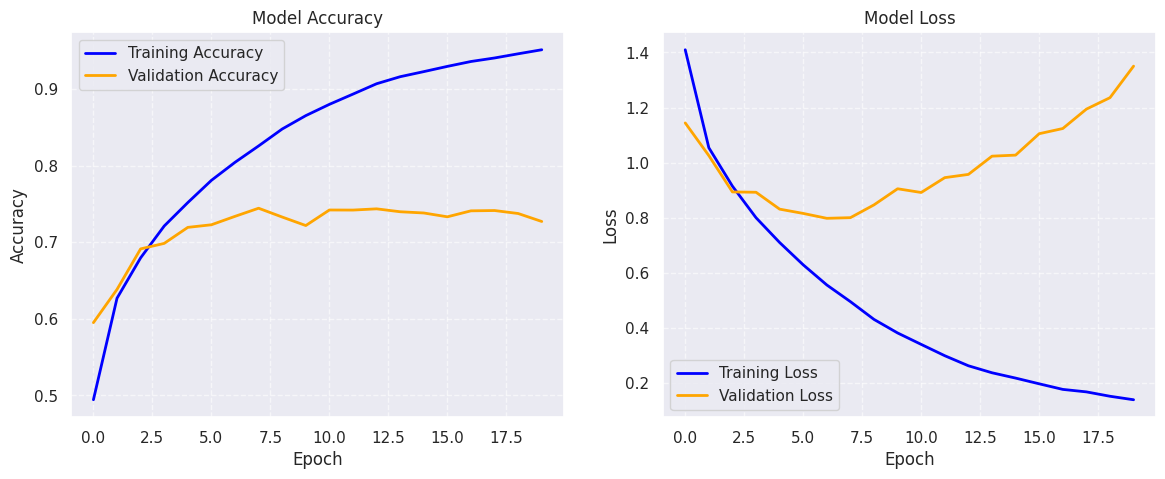

In [14]:
# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Accuracy ---
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Loss ---
ax2.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.show()

Fixing overfitting

Training Final Model with Early Stopping...
Epoch 1/20
782/782 [==============================] - 18s 22ms/step - loss: 1.4615 - accuracy: 0.4729 - val_loss: 1.1696 - val_accuracy: 0.5800
Epoch 2/20
782/782 [==============================] - 16s 21ms/step - loss: 1.1045 - accuracy: 0.6123 - val_loss: 1.0372 - val_accuracy: 0.6324
Epoch 3/20
782/782 [==============================] - 17s 21ms/step - loss: 0.9684 - accuracy: 0.6599 - val_loss: 0.9696 - val_accuracy: 0.6645
Epoch 4/20
782/782 [==============================] - 17s 21ms/step - loss: 0.8748 - accuracy: 0.6930 - val_loss: 0.8919 - val_accuracy: 0.6920
Epoch 5/20
782/782 [==============================] - 17s 22ms/step - loss: 0.7888 - accuracy: 0.7252 - val_loss: 0.9017 - val_accuracy: 0.6981
Epoch 6/20
782/782 [==============================] - 17s 22ms/step - loss: 0.7271 - accuracy: 0.7458 - val_loss: 0.8140 - val_accuracy: 0.7181
Epoch 7/20
782/782 [==============================] - 17s 21ms/step - loss: 0.6626 - accurac

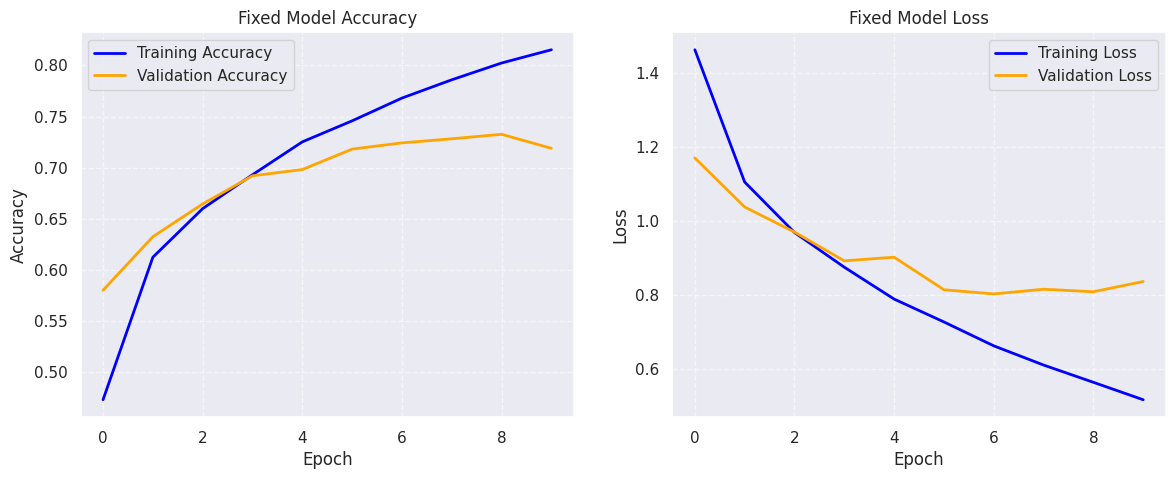

In [15]:
# 1. Define Early Stopping Callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         # Watch the validation loss
    patience=3,                 # If it goes up for 3 epochs in a row, trigger the brake
    restore_best_weights=True,  # Crucial: Roll the brain back to the lowest loss epoch!
    verbose=1
)

# 2. Re-build a fresh copy of best architecture
best_hps = tuners["Bayesian_Optimization"].get_best_hyperparameters(num_trials=1)[0]
fixed_model = tuners["Bayesian_Optimization"].hypermodel.build(best_hps)

print("Training Final Model with Early Stopping...")

# 3. Train the model
history_fixed = fixed_model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stopping], 
    verbose=1
)

# 4. Plot the new, fixed learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history_fixed.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
ax1.plot(history_fixed.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
ax1.set_title('Fixed Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Loss Plot
ax2.plot(history_fixed.history['loss'], label='Training Loss', color='blue', linewidth=2)
ax2.plot(history_fixed.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
ax2.set_title('Fixed Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.show()

Comparing and saving the final fixed model

In [16]:
# --- Part 1: Print the Scoreboard ---
print("\n" + "="*40)
print("--- FINAL ACCURACY SCOREBOARD ---")
print("="*40)
print(f"Baseline Architecture (3 Epochs): 61.08%")
print(f"Final Optimized Model (Early Stop): {history_fixed.history['val_accuracy'][-1]*100:.2f}%")
print("="*40 + "\n")

# --- Part 2: Save the Model to the Deliverables Folder ---

# Define the deliverables folder path
deliverables_folder = "../deliverables"

# Define the exact path and filename for your saved model
import os 

model_save_path = os.path.join(deliverables_folder, "optimized_cifar10_model.keras")

print(f"Saving final model to: {model_save_path} ...")

# 4. Save the model 
fixed_model.save(model_save_path) 

print("Model successfully saved!")


--- FINAL ACCURACY SCOREBOARD ---
Baseline Architecture (3 Epochs): 61.08%
Final Optimized Model (Early Stop): 71.89%

Saving final model to: ../deliverables/optimized_cifar10_model.keras ...
Model successfully saved!
